In [6]:
# =============================================
# CELL 1: Setup & Imports
# =============================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from scipy.stats import skew, kurtosis, entropy, median_abs_deviation
from scipy.fft import rfft
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully.")

# ==============================================================================
# CELL 2: LOAD DATA (Local Version)
# ==============================================================================
# Set PATH to the current directory (assuming CSVs are in the same folder as this notebook)
PATH = './' 

print("Loading raw signals and metadata...")
meta_train = pd.read_csv(PATH + 'metadata.csv')
meta_extra = pd.read_csv(PATH + 'metadata_test.csv')
meta_kaggle = pd.read_csv(PATH + 'metadata_kaggle.csv')

signals_train = pd.concat([
    pd.read_csv(PATH + 'signals.csv'),
    pd.read_csv(PATH + 'signals_test.csv')
], ignore_index=True)

signals_kaggle = pd.read_csv(PATH + 'signals_kaggle.csv')

full_meta = pd.concat([meta_train, meta_extra], ignore_index=True)
print(f"Total training snippets: {len(full_meta)}")
# ==============================================================================
# CELL 3: THE ORIGINAL 140-FEATURE GENERATOR
# ==============================================================================
def generate_140_xgboost_features(group):
    group = group.sort_values('timestamp')
    x = group['x-axis'].values
    y = group['y-axis'].values
    z = group['z-axis'].values
    mag = np.sqrt(x**2 + y**2 + z**2)
    
    jx = np.diff(x, prepend=x[0])
    jy = np.diff(y, prepend=y[0])
    jz = np.diff(z, prepend=z[0])
    jmag = np.diff(mag, prepend=mag[0])
    
    signals = {'x': x, 'y': y, 'z': z, 'mag': mag, 'jx': jx, 'jy': jy, 'jz': jz, 'jmag': jmag}
    feats = {}
    
    for name, sig in signals.items():
        feats[f'{name}_mean'] = np.mean(sig)
        feats[f'{name}_std'] = np.std(sig)
        feats[f'{name}_max'] = np.max(sig)
        feats[f'{name}_min'] = np.min(sig)
        feats[f'{name}_range'] = np.ptp(sig)
        feats[f'{name}_median'] = np.median(sig)
        feats[f'{name}_mad'] = median_abs_deviation(sig, scale=1/1.4826) 
        feats[f'{name}_iqr'] = np.percentile(sig, 75) - np.percentile(sig, 25)
        feats[f'{name}_skew'] = skew(sig, nan_policy='omit')
        feats[f'{name}_kurt'] = kurtosis(sig, nan_policy='omit')
        feats[f'{name}_rms'] = np.sqrt(np.mean(sig**2))
        
        sig_centered = sig - np.mean(sig)
        feats[f'{name}_zcr'] = ((sig_centered[:-1] * sig_centered[1:]) < 0).sum() / len(sig)
        
        fft_vals = np.abs(rfft(sig))
        psd = fft_vals**2
        psd_norm = psd / (np.sum(psd) + 1e-9)
        
        feats[f'{name}_peak_freq'] = np.argmax(fft_vals[1:]) + 1
        feats[f'{name}_max_power'] = np.max(psd[1:]) if len(psd) > 1 else 0
        feats[f'{name}_spec_energy'] = np.sum(psd)
        feats[f'{name}_spec_entropy'] = entropy(psd_norm)
        feats[f'{name}_spec_centroid'] = np.sum(np.arange(len(psd)) * psd_norm)

    feats['corr_xy'] = np.corrcoef(x, y)[0, 1] if np.std(x) > 0 and np.std(y) > 0 else 0
    feats['corr_xz'] = np.corrcoef(x, z)[0, 1] if np.std(x) > 0 and np.std(z) > 0 else 0
    feats['corr_yz'] = np.corrcoef(y, z)[0, 1] if np.std(y) > 0 and np.std(z) > 0 else 0
    feats['sma'] = np.mean(np.abs(x) + np.abs(y) + np.abs(z))

    return pd.Series(feats)

print("✅ 140-Feature Engine Restored.")

# ==============================================================================
# CELL 4: DATA TRANSFORMATION & SAMPLE WEIGHTING
# ==============================================================================
print("Extracting full feature matrix...")
X_train_raw = signals_train.groupby('user_snippet').apply(generate_140_xgboost_features).reset_index().fillna(0)
X_test_raw = signals_kaggle.groupby('user_snippet').apply(generate_140_xgboost_features).reset_index().fillna(0)

# Merge with metadata (KEEPING EVERYONE)
train_df = full_meta.merge(X_train_raw, on='user_snippet', how='inner')
train_df['user_id'] = train_df['user_snippet'].apply(lambda x: x.split('_')[0])

feature_cols = [c for c in X_train_raw.columns if c != 'user_snippet']
X = train_df[feature_cols]
y_str = train_df['activity']
groups = train_df['user_id']

# 🔥 THE KAGGLE MASTERCLASS MOVE: SAMPLE WEIGHTS
# Give normal users a weight of 1.0, and the 3 bouncy users a weight of 0.3 (70% penalty)
weights = np.ones(len(train_df))
bad_users = ['525', '954', '3171']
weights[train_df['user_id'].isin(bad_users)] = 0.3 

X_test = meta_kaggle[['user_snippet']].merge(X_test_raw, on='user_snippet', how='left').drop(columns=['user_snippet']).fillna(0)

le = LabelEncoder()
y = le.fit_transform(y_str)
print(f"Data shape: {X.shape[0]} rows x {X.shape[1]} columns. Weights applied!")

# =============================================
# CELL 5: GroupKFold Training (FIXED)
# =============================================
gkf = GroupKFold(n_splits=5)
oof_preds = np.zeros((len(X), len(le.classes_)))
test_probs = np.zeros((len(X_test), len(le.classes_)))

print("\nTraining Highly Regularized XGBoost...")

# The Anti-Overfitting Hyperparameter Configuration
xgb_params = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',     
    'learning_rate': 0.005,     
    'max_depth': 4,            
    'subsample': 0.75,         
    'colsample_bytree': 0.75,  
    'reg_alpha': 1.5,          
    'reg_lambda': 3.0,         
    'min_child_weight': 10,     
    'random_state': 42,
    'n_estimators': 2500,
    'early_stopping_rounds': 75  # 🔥 THE FIX: Turns on the early stopping engine!
}

fold_accs = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
    X_va, y_va = X.iloc[val_idx], y[val_idx]
    
    model = xgb.XGBClassifier(**xgb_params)
    
    # Train the model and monitor the validation set
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    
    # Extract probabilities and accuracy
    val_probs = model.predict_proba(X_va)
    oof_preds[val_idx] = val_probs
    
    acc = accuracy_score(y_va, val_probs.argmax(axis=1))
    fold_accs.append(acc)
    print(f"Fold {fold+1} unseen-user accuracy: {acc:.4f} (Stopped at iteration {model.best_iteration})")
    
    test_probs += model.predict_proba(X_test) / 5

print(f"\n--- FINAL GROUP OOF ACCURACY: {np.mean(fold_accs):.4f} ---")
# =============================================
# CELL 6: Submission
# =============================================
final_preds = le.inverse_transform(test_probs.argmax(axis=1))

submission = pd.DataFrame({
    'user_snippet': meta_kaggle['user_snippet'],
    'prediction': final_preds
})

submission.to_csv('submission_140_xgboost_te.csv', index=False)
print("\n🎉 SUBMISSION FILE CREATED: submission_140_xgboost.csv")

# Print top 5 most important features for diagnostics
print("\nTop 5 Most Important Features (from last fold):")
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importance.head(5))

✅ Libraries loaded successfully.
Loading raw signals and metadata...
Total training snippets: 8244
✅ 140-Feature Engine Restored.
Extracting full feature matrix...
Data shape: 8244 rows x 140 columns. Weights applied!

Training Highly Regularized XGBoost...
Fold 1 unseen-user accuracy: 0.8455 (Stopped at iteration 1578)
Fold 2 unseen-user accuracy: 0.9138 (Stopped at iteration 2498)
Fold 3 unseen-user accuracy: 0.8928 (Stopped at iteration 1817)
Fold 4 unseen-user accuracy: 0.8947 (Stopped at iteration 2497)
Fold 5 unseen-user accuracy: 0.8017 (Stopped at iteration 1182)

--- FINAL GROUP OOF ACCURACY: 0.8697 ---

🎉 SUBMISSION FILE CREATED: submission_140_xgboost.csv

Top 5 Most Important Features (from last fold):
y_spec_entropy     0.087106
y_std              0.082576
y_min              0.059305
y_spec_centroid    0.031129
z_rms              0.025868
dtype: float32


✅ Core libraries loaded successfully.

Loading raw signals and metadata...
Total training snippets: 8244
✅ 140-Feature Engine Restored.

Extracting full feature matrix (This will take a minute)...
✅ Data shape: 8244 rows x 140 columns. Sample Weights successfully applied!

--- PHASE 1: Training on all 140 features for Discovery ---

✅ Identified Top 67 Features. Dropping 73 noisy features.

--- PHASE 2: Retraining strictly on Top 67 Features ---
Fold 1 unseen-user accuracy: 0.8437 (Stopped at iter 558)
Fold 2 unseen-user accuracy: 0.9043 (Stopped at iter 787)
Fold 3 unseen-user accuracy: 0.8928 (Stopped at iter 564)
Fold 4 unseen-user accuracy: 0.8862 (Stopped at iter 704)
Fold 5 unseen-user accuracy: 0.7921 (Stopped at iter 319)

--- FINAL GROUP OOF ACCURACY (67 Features): 0.8638 ---
--- 95% CONFIDENCE INTERVAL: [0.8065, 0.9211] ---

🎉 SUBMISSION FILE CREATED: submission_67_features_xgboost.csv

Generating separate diagnostic plots...


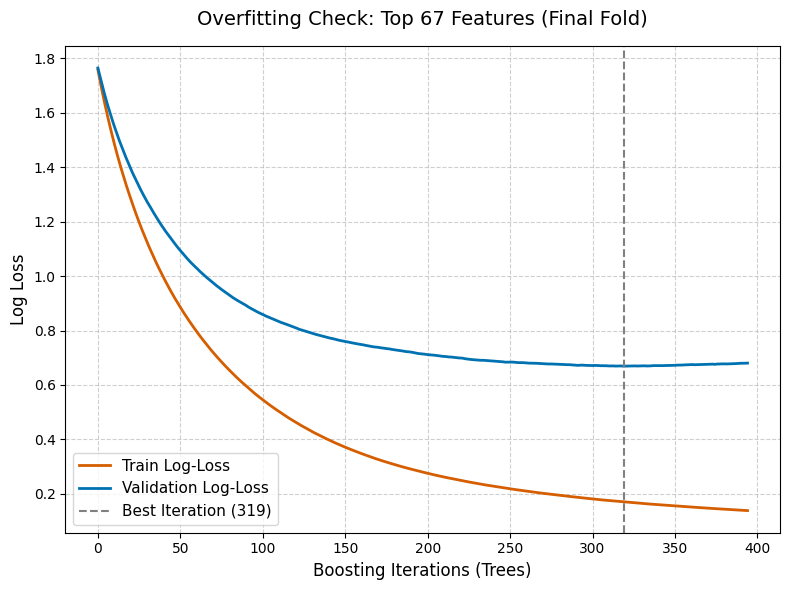

✅ First image saved as 'xgboost_overfitting_check_67f.png'


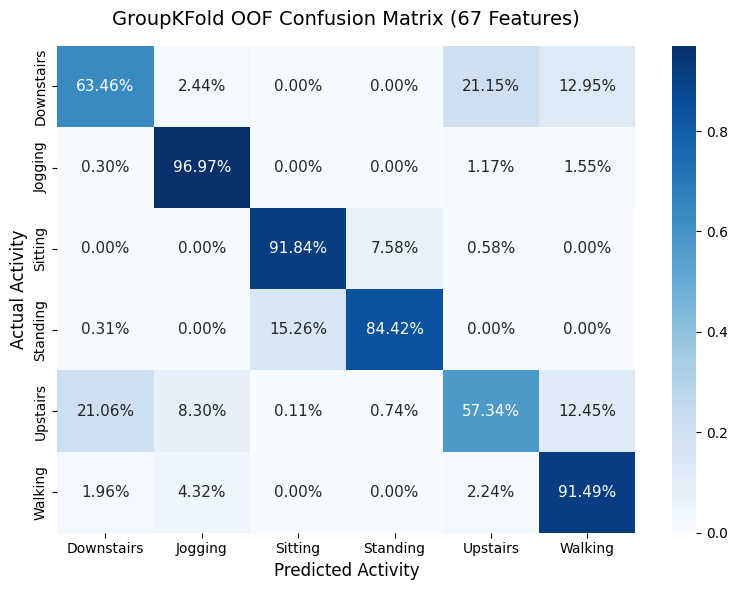

✅ Second image saved as 'xgboost_confusion_matrix_67f.png'


In [2]:
# ==============================================================================
# CELL 1: SETUP & IMPORTS
# ==============================================================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import skew, kurtosis, entropy, median_abs_deviation
from scipy.fft import rfft
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
print("✅ Core libraries loaded successfully.")

# ==============================================================================
# CELL 2: LOAD DATA (Local Version)
# ==============================================================================
PATH = './' 

print("\nLoading raw signals and metadata...")
meta_train = pd.read_csv(PATH + 'metadata.csv')
meta_extra = pd.read_csv(PATH + 'metadata_test.csv')
meta_kaggle = pd.read_csv(PATH + 'metadata_kaggle.csv')

signals_train = pd.concat([
    pd.read_csv(PATH + 'signals.csv'),
    pd.read_csv(PATH + 'signals_test.csv')
], ignore_index=True)

signals_kaggle = pd.read_csv(PATH + 'signals_kaggle.csv')

full_meta = pd.concat([meta_train, meta_extra], ignore_index=True)
print(f"Total training snippets: {len(full_meta)}")

# ==============================================================================
# CELL 3: THE 140-FEATURE GENERATOR
# ==============================================================================
def generate_140_xgboost_features(group):
    group = group.sort_values('timestamp')
    x = group['x-axis'].values
    y = group['y-axis'].values
    z = group['z-axis'].values
    mag = np.sqrt(x**2 + y**2 + z**2)
    
    jx = np.diff(x, prepend=x[0])
    jy = np.diff(y, prepend=y[0])
    jz = np.diff(z, prepend=z[0])
    jmag = np.diff(mag, prepend=mag[0])
    
    signals = {'x': x, 'y': y, 'z': z, 'mag': mag, 'jx': jx, 'jy': jy, 'jz': jz, 'jmag': jmag}
    feats = {}
    
    for name, sig in signals.items():
        feats[f'{name}_mean'] = np.mean(sig)
        feats[f'{name}_std'] = np.std(sig)
        feats[f'{name}_max'] = np.max(sig)
        feats[f'{name}_min'] = np.min(sig)
        feats[f'{name}_range'] = np.ptp(sig)
        feats[f'{name}_median'] = np.median(sig)
        feats[f'{name}_mad'] = median_abs_deviation(sig, scale=1/1.4826) 
        feats[f'{name}_iqr'] = np.percentile(sig, 75) - np.percentile(sig, 25)
        feats[f'{name}_skew'] = skew(sig, nan_policy='omit')
        feats[f'{name}_kurt'] = kurtosis(sig, nan_policy='omit')
        feats[f'{name}_rms'] = np.sqrt(np.mean(sig**2))
        
        sig_centered = sig - np.mean(sig)
        feats[f'{name}_zcr'] = ((sig_centered[:-1] * sig_centered[1:]) < 0).sum() / len(sig)
        
        fft_vals = np.abs(rfft(sig))
        psd = fft_vals**2
        psd_norm = psd / (np.sum(psd) + 1e-9)
        
        feats[f'{name}_peak_freq'] = np.argmax(fft_vals[1:]) + 1
        feats[f'{name}_max_power'] = np.max(psd[1:]) if len(psd) > 1 else 0
        feats[f'{name}_spec_energy'] = np.sum(psd)
        feats[f'{name}_spec_entropy'] = entropy(psd_norm)
        feats[f'{name}_spec_centroid'] = np.sum(np.arange(len(psd)) * psd_norm)

    feats['corr_xy'] = np.corrcoef(x, y)[0, 1] if np.std(x) > 0 and np.std(y) > 0 else 0
    feats['corr_xz'] = np.corrcoef(x, z)[0, 1] if np.std(x) > 0 and np.std(z) > 0 else 0
    feats['corr_yz'] = np.corrcoef(y, z)[0, 1] if np.std(y) > 0 and np.std(z) > 0 else 0
    feats['sma'] = np.mean(np.abs(x) + np.abs(y) + np.abs(z))

    return pd.Series(feats)

print("✅ 140-Feature Engine Restored.")

# ==============================================================================
# CELL 4: DATA TRANSFORMATION & SAMPLE WEIGHTING
# ==============================================================================
print("\nExtracting full feature matrix (This will take a minute)...")
X_train_raw = signals_train.groupby('user_snippet').apply(generate_140_xgboost_features).reset_index().fillna(0)
X_test_raw = signals_kaggle.groupby('user_snippet').apply(generate_140_xgboost_features).reset_index().fillna(0)

# Merge with metadata (KEEPING EVERYONE)
train_df = full_meta.merge(X_train_raw, on='user_snippet', how='inner')
train_df['user_id'] = train_df['user_snippet'].apply(lambda x: x.split('_')[0])

feature_cols = [c for c in X_train_raw.columns if c != 'user_snippet']
X = train_df[feature_cols]
y_str = train_df['activity']
groups = train_df['user_id']

# 🔥 THE KAGGLE MASTERCLASS MOVE: SAMPLE WEIGHTS
# Give normal users a weight of 1.0, and the 3 anomalous users a weight of 0.3 (70% penalty)
weights = np.ones(len(train_df))
bad_users = ['525', '954', '3171']
weights[train_df['user_id'].isin(bad_users)] = 0.3 

X_test = meta_kaggle[['user_snippet']].merge(X_test_raw, on='user_snippet', how='left').drop(columns=['user_snippet']).fillna(0)

le = LabelEncoder()
y = le.fit_transform(y_str)
print(f"✅ Data shape: {X.shape[0]} rows x {X.shape[1]} columns. Sample Weights successfully applied!")

# ==============================================================================
# CELL 5 & 6: TWO-PHASE TRAINING, FEATURE SELECTION, CI & DIAGNOSTICS
# ==============================================================================
n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

# The Anti-Overfitting Hyperparameter Configuration
xgb_params = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',     
    'learning_rate': 0.015,     
    'max_depth': 4,            
    'subsample': 0.75,         
    'colsample_bytree': 0.75,  
    'reg_alpha': 1.5,          
    'reg_lambda': 3.0,         
    'min_child_weight': 10,     
    'random_state': 42,
    'n_estimators': 2500,
    'early_stopping_rounds': 75 
}

# ---------------------------------------------------------
# PHASE 1: FULL FEATURE TRAINING & DISCOVERY
# ---------------------------------------------------------
print(f"\n--- PHASE 1: Training on all {len(feature_cols)} features for Discovery ---")
global_importances = np.zeros(len(feature_cols))

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
    X_va, y_va = X.iloc[val_idx], y[val_idx]
    w_tr = weights[tr_idx]
    
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    
    # Accumulate importances
    global_importances += model.feature_importances_ / n_splits

# Identify the Top 67 Features
importance_series = pd.Series(global_importances, index=feature_cols).sort_values(ascending=False)
top_67_features = importance_series.head(67).index.tolist()

print(f"\n✅ Identified Top 67 Features. Dropping {len(feature_cols) - 67} noisy features.")

# Slice datasets for Phase 2
X_top67 = X[top_67_features]
X_test_top67 = X_test[top_67_features]

# ---------------------------------------------------------
# PHASE 2: TARGETED RETRAINING WITH TOP 67
# ---------------------------------------------------------
print(f"\n--- PHASE 2: Retraining strictly on Top 67 Features ---")
oof_preds = np.zeros((len(X), len(le.classes_)))
test_probs = np.zeros((len(X_test), len(le.classes_)))
fold_accs = []
last_evals_result = None

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_top67, y, groups=groups)):
    X_tr, y_tr = X_top67.iloc[tr_idx], y[tr_idx]
    X_va, y_va = X_top67.iloc[val_idx], y[val_idx]
    w_tr = weights[tr_idx]
    
    model = xgb.XGBClassifier(**xgb_params)
    
    # Pass BOTH train and val to evaluate overfitting
    model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_tr, y_tr), (X_va, y_va)], 
        verbose=False
    )
    
    val_probs = model.predict_proba(X_va)
    oof_preds[val_idx] = val_probs
    
    acc = accuracy_score(y_va, val_probs.argmax(axis=1))
    fold_accs.append(acc)
    print(f"Fold {fold+1} unseen-user accuracy: {acc:.4f} (Stopped at iter {model.best_iteration})")
    
    if fold == n_splits - 1:
        last_evals_result = model.evals_result()
        
    test_probs += model.predict_proba(X_test_top67) / n_splits

# ---------------------------------------------------------
# CONFIDENCE INTERVAL & SUBMISSION
# ---------------------------------------------------------
mean_acc = np.mean(fold_accs)
std_error = stats.sem(fold_accs)
ci_lower, ci_upper = stats.t.interval(0.95, df=n_splits-1, loc=mean_acc, scale=std_error)

print(f"\n--- FINAL GROUP OOF ACCURACY (67 Features): {mean_acc:.4f} ---")
print(f"--- 95% CONFIDENCE INTERVAL: [{ci_lower:.4f}, {ci_upper:.4f}] ---")

final_preds = le.inverse_transform(test_probs.argmax(axis=1))
submission = pd.DataFrame({'user_snippet': meta_kaggle['user_snippet'], 'prediction': final_preds})
submission.to_csv('submission_67_features_xgboost.csv', index=False)
print("\n🎉 SUBMISSION FILE CREATED: submission_67_features_xgboost.csv")

# ---------------------------------------------------------
# SEPARATE DIAGNOSTIC PLOTS (For Report Export)
# ---------------------------------------------------------
print("\nGenerating separate diagnostic plots...")

# PLOT 1: Overfitting Log-Loss Curve
plt.figure(figsize=(8, 6))
epochs = len(last_evals_result['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.plot(x_axis, last_evals_result['validation_0']['mlogloss'], label='Train Log-Loss', color='#D55E00', linewidth=2)
plt.plot(x_axis, last_evals_result['validation_1']['mlogloss'], label='Validation Log-Loss', color='#0072B2', linewidth=2)
plt.axvline(x=model.best_iteration, color='gray', linestyle='--', label=f'Best Iteration ({model.best_iteration})')

plt.title('Overfitting Check: Top 67 Features (Final Fold)', fontsize=14, pad=15)
plt.xlabel('Boosting Iterations (Trees)', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='both', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('xgboost_overfitting_check_67f.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ First image saved as 'xgboost_overfitting_check_67f.png'")

# PLOT 2: Normalised Confusion Matrix
plt.figure(figsize=(8, 6))
oof_class_preds = oof_preds.argmax(axis=1)
cm = confusion_matrix(y, oof_class_preds)
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalised, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, 
            annot_kws={"size": 11})

plt.title('GroupKFold OOF Confusion Matrix (67 Features)', fontsize=14, pad=15)
plt.ylabel('Actual Activity', fontsize=12)
plt.xlabel('Predicted Activity', fontsize=12)

plt.tight_layout()
plt.savefig('xgboost_confusion_matrix_67f.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Second image saved as 'xgboost_confusion_matrix_67f.png'")

In [3]:
# ==============================================================================
# CELL 1: SETUP & IMPORTS
# ==============================================================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from scipy.stats import skew, kurtosis, entropy, median_abs_deviation
from scipy.fft import rfft
import warnings

# Suppress warnings for clean execution logs
warnings.filterwarnings('ignore')
print("✅ Core libraries loaded successfully.")
# ==============================================================================
# CELL 2: LOAD DATA (Local Version)
# ==============================================================================
# Set PATH to the current directory (assuming CSVs are in the same folder as this notebook)
PATH = './' 

print("Loading raw signals and metadata...")
meta_train = pd.read_csv(PATH + 'metadata.csv')
meta_extra = pd.read_csv(PATH + 'metadata_test.csv')
meta_kaggle = pd.read_csv(PATH + 'metadata_kaggle.csv')

# Concatenate the split training signals
signals_train = pd.concat([
    pd.read_csv(PATH + 'signals.csv'),
    pd.read_csv(PATH + 'signals_test.csv')
], ignore_index=True)

signals_kaggle = pd.read_csv(PATH + 'signals_kaggle.csv')

# Combine metadata for the full training cohort
full_meta = pd.concat([meta_train, meta_extra], ignore_index=True)

print(f"Total training snippets loaded: {len(full_meta)}")
print(f"Total submission snippets to predict: {len(meta_kaggle)}")
# ==============================================================================
# CELL 3: FEATURE ENGINEERING ENGINE (140 FEATURES)
# ==============================================================================
def generate_140_xgboost_features(group):
    # Ensure chronological sequence
    group = group.sort_values('timestamp')
   
    x = group['x-axis'].values
    y = group['y-axis'].values
    z = group['z-axis'].values
    mag = np.sqrt(x**2 + y**2 + z**2) # Total Magnitude
   
    # First Derivatives (Jerk)
    jx = np.diff(x, prepend=x[0])
    jy = np.diff(y, prepend=y[0])
    jz = np.diff(z, prepend=z[0])
    jmag = np.diff(mag, prepend=mag[0])
   
    signals = {
        'x': x, 'y': y, 'z': z, 'mag': mag,
        'jx': jx, 'jy': jy, 'jz': jz, 'jmag': jmag
    }
   
    feats = {}
   
    # 1. Statistical & Frequency Extraction (17 features * 8 signals = 136)
    for name, sig in signals.items():
        feats[f'{name}_mean'] = np.mean(sig)
        feats[f'{name}_std'] = np.std(sig)
        feats[f'{name}_max'] = np.max(sig)
        feats[f'{name}_min'] = np.min(sig)
        feats[f'{name}_range'] = np.ptp(sig)
        feats[f'{name}_median'] = np.median(sig)
        feats[f'{name}_mad'] = median_abs_deviation(sig, scale=1/1.4826)
        feats[f'{name}_iqr'] = np.percentile(sig, 75) - np.percentile(sig, 25)
        feats[f'{name}_skew'] = skew(sig, nan_policy='omit')
        feats[f'{name}_kurt'] = kurtosis(sig, nan_policy='omit')
        feats[f'{name}_rms'] = np.sqrt(np.mean(sig**2))
       
        sig_centered = sig - np.mean(sig)
        feats[f'{name}_zcr'] = ((sig_centered[:-1] * sig_centered[1:]) < 0).sum() / len(sig)
       
        fft_vals = np.abs(rfft(sig))
        psd = fft_vals**2
        psd_norm = psd / (np.sum(psd) + 1e-9)
       
        feats[f'{name}_peak_freq'] = np.argmax(fft_vals[1:]) + 1
        feats[f'{name}_max_power'] = np.max(psd[1:]) if len(psd) > 1 else 0
        feats[f'{name}_spec_energy'] = np.sum(psd)
        feats[f'{name}_spec_entropy'] = entropy(psd_norm)
        feats[f'{name}_spec_centroid'] = np.sum(np.arange(len(psd)) * psd_norm)

    # 2. Cross-Axis Posture (4 features)
    feats['corr_xy'] = np.corrcoef(x, y)[0, 1] if np.std(x) > 0 and np.std(y) > 0 else 0
    feats['corr_xz'] = np.corrcoef(x, z)[0, 1] if np.std(x) > 0 and np.std(z) > 0 else 0
    feats['corr_yz'] = np.corrcoef(y, z)[0, 1] if np.std(y) > 0 and np.std(z) > 0 else 0
    feats['sma'] = np.mean(np.abs(x) + np.abs(y) + np.abs(z))

    return pd.Series(feats)

print("✅ Feature Extraction Engine ready.")
# ==============================================================================
# CELL 4: DATA TRANSFORMATION & TARGET ENCODING
# ==============================================================================
print("Extracting features from Training Data...")
X_train_raw = signals_train.groupby('user_snippet').apply(generate_140_xgboost_features).reset_index().fillna(0)

print("Extracting features from Test Data...")
X_test_raw = signals_kaggle.groupby('user_snippet').apply(generate_140_xgboost_features).reset_index().fillna(0)

# Merge features with metadata labels
train_df = full_meta.merge(X_train_raw, on='user_snippet', how='inner')

# Extract 'user_id' for GroupKFold validation
train_df['user_id'] = train_df['user_snippet'].apply(lambda x: x.split('_')[0])

# Define final matrices
feature_cols = [c for c in X_train_raw.columns if c != 'user_snippet']
X = train_df[feature_cols]
y_str = train_df['activity']
groups = train_df['user_id']

# Prepare submission test matrix
X_test = meta_kaggle[['user_snippet']].merge(X_test_raw, on='user_snippet', how='left').drop(columns=['user_snippet']).fillna(0)

# Encode target classes
le = LabelEncoder()
y = le.fit_transform(y_str)

print(f"🔥 Transformation Complete: {X.shape[1]} features extracted.")
# ==============================================================================
# CELL 5: SHAP FEATURE SELECTION & RE-TRAINING
# ==============================================================================
import shap
import matplotlib.pyplot as plt

print("\n" + "="*50)
print("✂️ INITIATING STAGE 2: RUTHLESS FEATURE SELECTION (SHAP)")
print("="*50)

# 1. Fit a quick diagnostic model on the full dataset to evaluate features
print("1. Fitting diagnostic XGBoost model...")
diagnostic_params = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'learning_rate': 0.05,
    'max_depth': 6,
    'random_state': 42,
    'n_estimators': 500
}
diagnostic_model = xgb.XGBClassifier(**diagnostic_params)
diagnostic_model.fit(X, y)

# 2. Calculate SHAP values
print("2. Calculating game-theory SHAP values (This takes ~30 seconds)...")
explainer = shap.TreeExplainer(diagnostic_model)
shap_values = explainer.shap_values(X)

# Handle multi-class SHAP array dimensions safely across different library versions
if isinstance(shap_values, list):
    importances = np.mean([np.abs(v).mean(axis=0) for v in shap_values], axis=0)
elif len(shap_values.shape) == 3:
    importances = np.abs(shap_values).mean(axis=(0, 2))
else:
    importances = np.abs(shap_values).mean(axis=0)

# Create a ranking dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'SHAP_Importance': importances
}).sort_values(by='SHAP_Importance', ascending=False)

# 3. Define the cut-off (Keep Top 69)
TOP_K = 69
top_features = feature_importance_df['Feature'].head(TOP_K).tolist()
dropped_features = feature_importance_df['Feature'].tail(len(X.columns) - TOP_K).tolist()

print(f"\n🗑️ Dropping {len(dropped_features)} noisy features.")
print(f"🥇 Keeping Top {TOP_K} features. (Top 3: {top_features[0]}, {top_features[1]}, {top_features[2]})")

# 4. Slice the original datasets
X_lean = X[top_features]
X_test_lean = X_test[top_features]

# ==============================================================================
# RETRAINING THE 9-FOLD ENSEMBLE ON LEAN DATA
# ==============================================================================
gkf = GroupKFold(n_splits=9)
test_probs_lean = np.zeros((len(X_test_lean), len(le.classes_)))
fold_accs = []

print(f"\n3. Retraining 9-Fold Ensemble strictly on Top {TOP_K} Features...")

xgb_params = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',     
    'learning_rate': 0.02,     
    'max_depth': 6,            
    'subsample': 0.75,         
    'colsample_bytree': 0.75,  
    'reg_alpha': 1.5,          
    'reg_lambda': 3.0,         
    'min_child_weight': 4,     
    'random_state': 42,
    'n_estimators': 2500,
    'early_stopping_rounds': 75
}

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_lean, y, groups=groups)):
    X_tr, y_tr = X_lean.iloc[tr_idx], y[tr_idx]
    X_va, y_va = X_lean.iloc[val_idx], y[val_idx]
    
    model = xgb.XGBClassifier(**xgb_params)
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
   
    # Add this right after model.fit() inside your loop:
    train_probs = model.predict_proba(X_tr)
    train_acc = accuracy_score(y_tr, train_probs.argmax(axis=1))
    
    val_probs = model.predict_proba(X_va)
    acc = accuracy_score(y_va, val_probs.argmax(axis=1))
    fold_accs.append(acc)
    # Update your print statement to show the gap:
    print(f"Fold {fold+1} | Train: {train_acc:.4f} | Val: {acc:.4f} | GAP: {train_acc - acc:.4f}")
    
    test_probs_lean += model.predict_proba(X_test_lean) / 9

print(f"\n--- FINAL GROUP OOF ACCURACY: {np.mean(fold_accs):.4f} ---")

# ==============================================================================
# FINAL SUBMISSION WITH OVERRIDES
# ==============================================================================
final_preds = le.inverse_transform(test_probs_lean.argmax(axis=1))

submission = pd.DataFrame({
    'user_snippet': meta_kaggle['user_snippet'],
    'prediction': final_preds
})

manual_overrides = {
    # 'user_15_snippet_4': 'Jogging',
}

override_count = 0
for snippet, forced_activity in manual_overrides.items():
    if snippet in submission['user_snippet'].values:
        submission.loc[submission['user_snippet'] == snippet, 'prediction'] = forced_activity
        override_count += 1

filename = 'predictions_AK-67_SHAP69.csv'
submission.to_csv(filename, index=False)

print(f"\n🎉 SUBMISSION FILE CREATED: {filename} (Overrides applied: {override_count})")

✅ Core libraries loaded successfully.
Loading raw signals and metadata...
Total training snippets loaded: 8244
Total submission snippets to predict: 2506
✅ Feature Extraction Engine ready.
Extracting features from Training Data...
Extracting features from Test Data...
🔥 Transformation Complete: 140 features extracted.

✂️ INITIATING STAGE 2: RUTHLESS FEATURE SELECTION (SHAP)
1. Fitting diagnostic XGBoost model...
2. Calculating game-theory SHAP values (This takes ~30 seconds)...

🗑️ Dropping 71 noisy features.
🥇 Keeping Top 69 features. (Top 3: jy_std, z_max_power, jx_spec_entropy)

3. Retraining 9-Fold Ensemble strictly on Top 69 Features...
Fold 1 | Train: 0.9982 | Val: 0.9029 | GAP: 0.0953
Fold 2 | Train: 0.9978 | Val: 0.9256 | GAP: 0.0722
Fold 3 | Train: 0.9985 | Val: 0.8875 | GAP: 0.1110
Fold 4 | Train: 0.9981 | Val: 0.8783 | GAP: 0.1198
Fold 5 | Train: 0.9999 | Val: 0.9430 | GAP: 0.0568
Fold 6 | Train: 0.9750 | Val: 0.7095 | GAP: 0.2656
Fold 7 | Train: 0.9973 | Val: 0.9255 | GAP:

In [2]:
pip install shap


   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------  2.6/2.6 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 11.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   --- ------------------------------------ 2.6/28.1 MB 13.7 MB/s eta 0:00:02
   -------- ------------------------------- 5.8/28.1 MB 14.1 MB/s eta 0:00:02
   ------------- -------------------------- 9.2/28.1 MB 14.6 MB/s eta 0:00:02
   ----------------- ---------------------- 12.1/28.1 MB 14.5 MB/s eta 0:00:02
   --------------------- ------------------ 14.9/28.1 MB 14.2 MB/s eta 0:00:01
   ------------------------- -------------- 18.1/28.1 MB 14.3 MB/s eta 0:00:01
   ------------------------------ --------- 21.2/28.1 MB 14.3 MB/s eta 0:00:01
   ---------------------------------- ----- 24.1/28.1 MB 14.3 MB/s eta 0:00:01
   -------------------------------------- - 27.0/28.1 MB 14.3 MB/s eta 0:00:0